Individual Tree Predictions: [np.float64(300.0), np.float64(250.0), np.float64(300.0)]
Final Bagging Prediction: 283.33


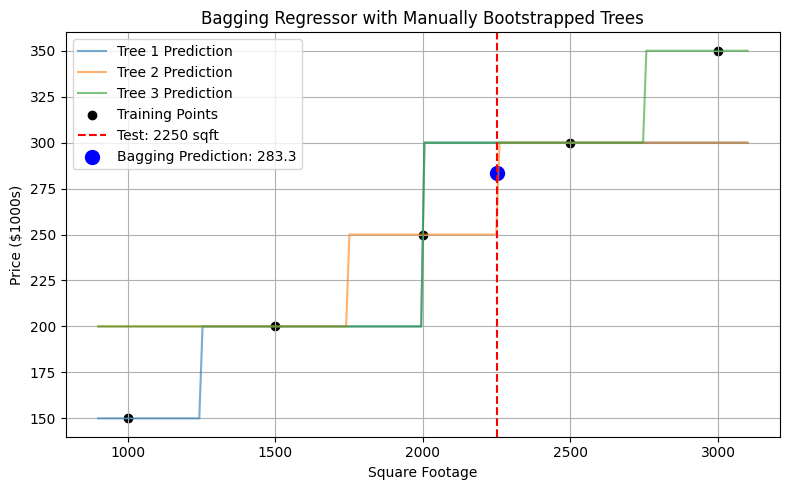

'Output -\nIndividual Tree Predictions: [np.float64(300.0), np.float64(250.0), np.float64(300.0)]\nFinal Bagging Prediction: 283.33\n'

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Original dataset
X = np.array([[1000], [1500], [2000], [2500], [3000]])
y = np.array([150, 200, 250, 300, 350])
# New test point
X_test = np.array([[2250]])
# Bootstrap Samples
bootstraps = [
   ([1000, 1500, 2500], [150, 200, 300]),     # Tree 1
   ([1500, 2000, 2500], [200, 250, 300]),     # Tree 2
   ([1500, 3000, 2500], [200, 350, 300])      # Tree 3
]
# Train and predict with each tree
predictions = []
models = []
for Xb, yb in bootstraps:
   model = DecisionTreeRegressor()
   model.fit(np.array(Xb).reshape(-1,1), np.array(yb))
   pred = model.predict(X_test)[0]
   predictions.append(pred)
   models.append(model)
# Final bagging prediction
bagging_prediction = np.mean(predictions)
print("Individual Tree Predictions:", predictions)
print("Final Bagging Prediction:", round(bagging_prediction, 2))
# Plot
plt.figure(figsize=(8, 5))
x_range = np.linspace(900, 3100, 200).reshape(-1, 1)
for i, model in enumerate(models):
   y_plot = model.predict(x_range)
   plt.plot(x_range, y_plot, label=f'Tree {i+1} Prediction', alpha=0.6)
# Plot original points
plt.scatter(X, y, color='black', label='Training Points')
plt.axvline(x=2250, color='red', linestyle='--', label='Test: 2250 sqft')
plt.scatter([2250], [bagging_prediction], color='blue', s=100, label=f'Bagging Prediction: {round(bagging_prediction,1)}')
plt.title("Bagging Regressor with Manually Bootstrapped Trees")
plt.xlabel("Square Footage")
plt.ylabel("Price ($1000s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
'''Output -
Individual Tree Predictions: [np.float64(300.0), np.float64(250.0), np.float64(300.0)]
Final Bagging Prediction: 283.33
'''